# project head embeddings

using the head distances from notebook 03, project the heads (labelling some known ones) into a 2D space.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import muutils.tensor_info
import polars as pl
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.attnpedia.attnpedia import AttentionPedia
from attention_motifs.features.analysis import DistanceTensorResult
from attention_motifs.features.head_analysis import (
	create_embedding_df_multi,
	plot_head_embeddings,
	plot_head_embeddings_multi,
)

In [2]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/")

# load dists

In [3]:
# load head distances
HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.read(
	PATH_BASE / "features" / "head_dists.zanj",
)
dbg_tensor(HEAD_DISTS.distances)
dbg_tensor(HEAD_DISTS.mean_dists)
# load attentionpedia
ATTENTIONPEDIA: AttentionPedia = AttentionPedia()

[ <ipykernel>:5 ] HEAD_DISTS.distances: μ=10.39 σ=4.40 x̃=9.64 R=[0.00,29.50] ℙ=| ▇█▄▁  | shape=(272,272) dtype=float64
[ <ipykernel>:6 ] HEAD_DISTS.mean_dists: μ=10.39 σ=4.40 x̃=9.64 R=[0.00,29.50] ℙ=| ▇█▄▁  | shape=(272,272) dtype=float64


In [4]:
ATTENTIONPEDIA.type_to_heads().keys()

dict_keys(['IOI:Previous Token', 'IOI:Duplicate Token', 'IOI:Induction', 'IOI:S-Inhibition', 'IOI:Negative Name Mover', 'IOI:Name Mover', 'IOI:Backup Name Mover', 'SAE-survey:Induction', 'SAE-survey:Previous Token', 'SAE-survey:Copy Suppression', 'SAE-survey:Duplicate Token', 'SAE-survey:Successor', 'SAE-survey:Long Range Context Tracking', 'greater-than:YY Identifier', 'greater-than:Static-Year Retriever'])

# head projection & clustering

  0%|          | 0/48 [00:00<?, ?it/s]~/attn-motifs-anon/.venv/lib/python3.13/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
~/attn-motifs-anon/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
~/attn-motifs-anon/.venv/lib/python3.13/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
~/attn-motifs-anon/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsi

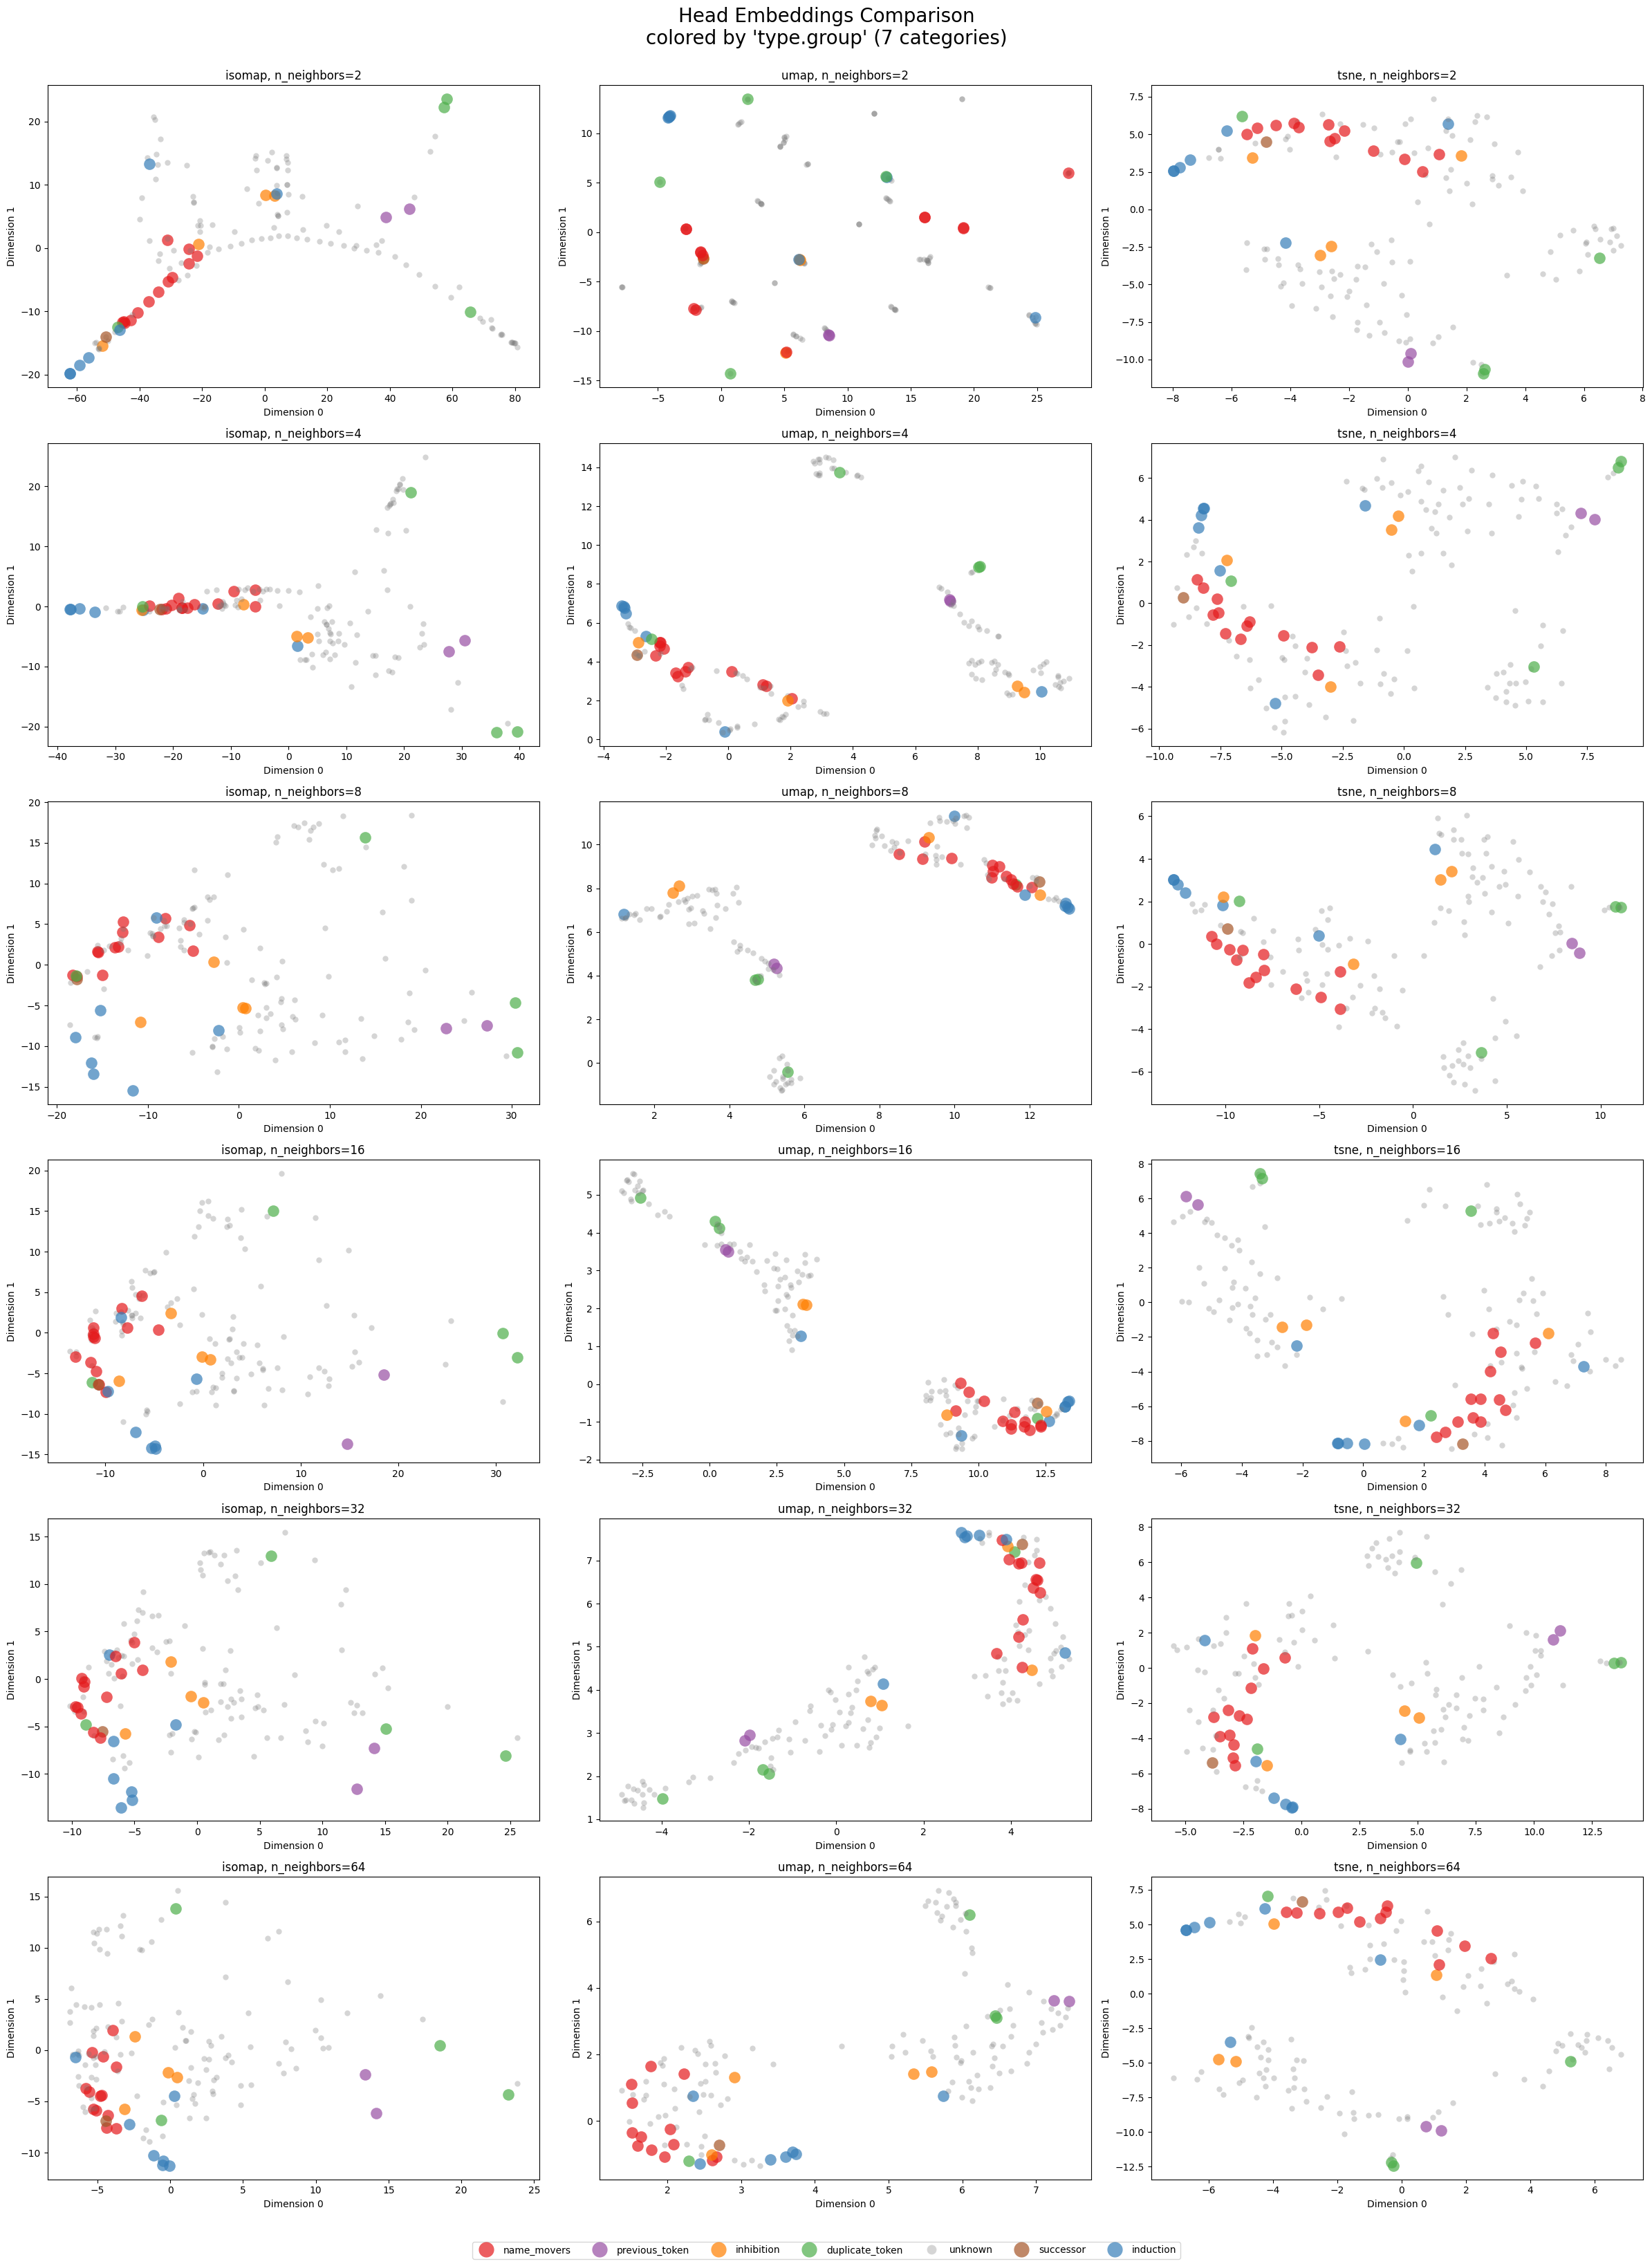

In [5]:
HEAD_EMBED_DF_GPT2SMALL: pl.DataFrame = create_embedding_df_multi(
	head_dists=HEAD_DISTS,
	attnpedia=ATTENTIONPEDIA,
	embedding_methods=["isomap", "umap", "tsne", "pca"],
	n_components_list=[2, 3],
	n_neighbors_list=[2, 4, 8, 16, 32, 64],
	match_model="gpt2-small",
	save_path=PATH_BASE / "head_embed",
)
_ = plot_head_embeddings_multi(
	HEAD_EMBED_DF_GPT2SMALL,
	color_by="type.group",
	methods=["isomap", "umap", "tsne"],
	sizes=(12, 6),
	figsize=(24, 32),
)
plt.savefig("figures/head_embed.gpt2-small.pdf", bbox_inches="tight")

100%|██████████| 48/48 [00:09<00:00,  5.32it/s]


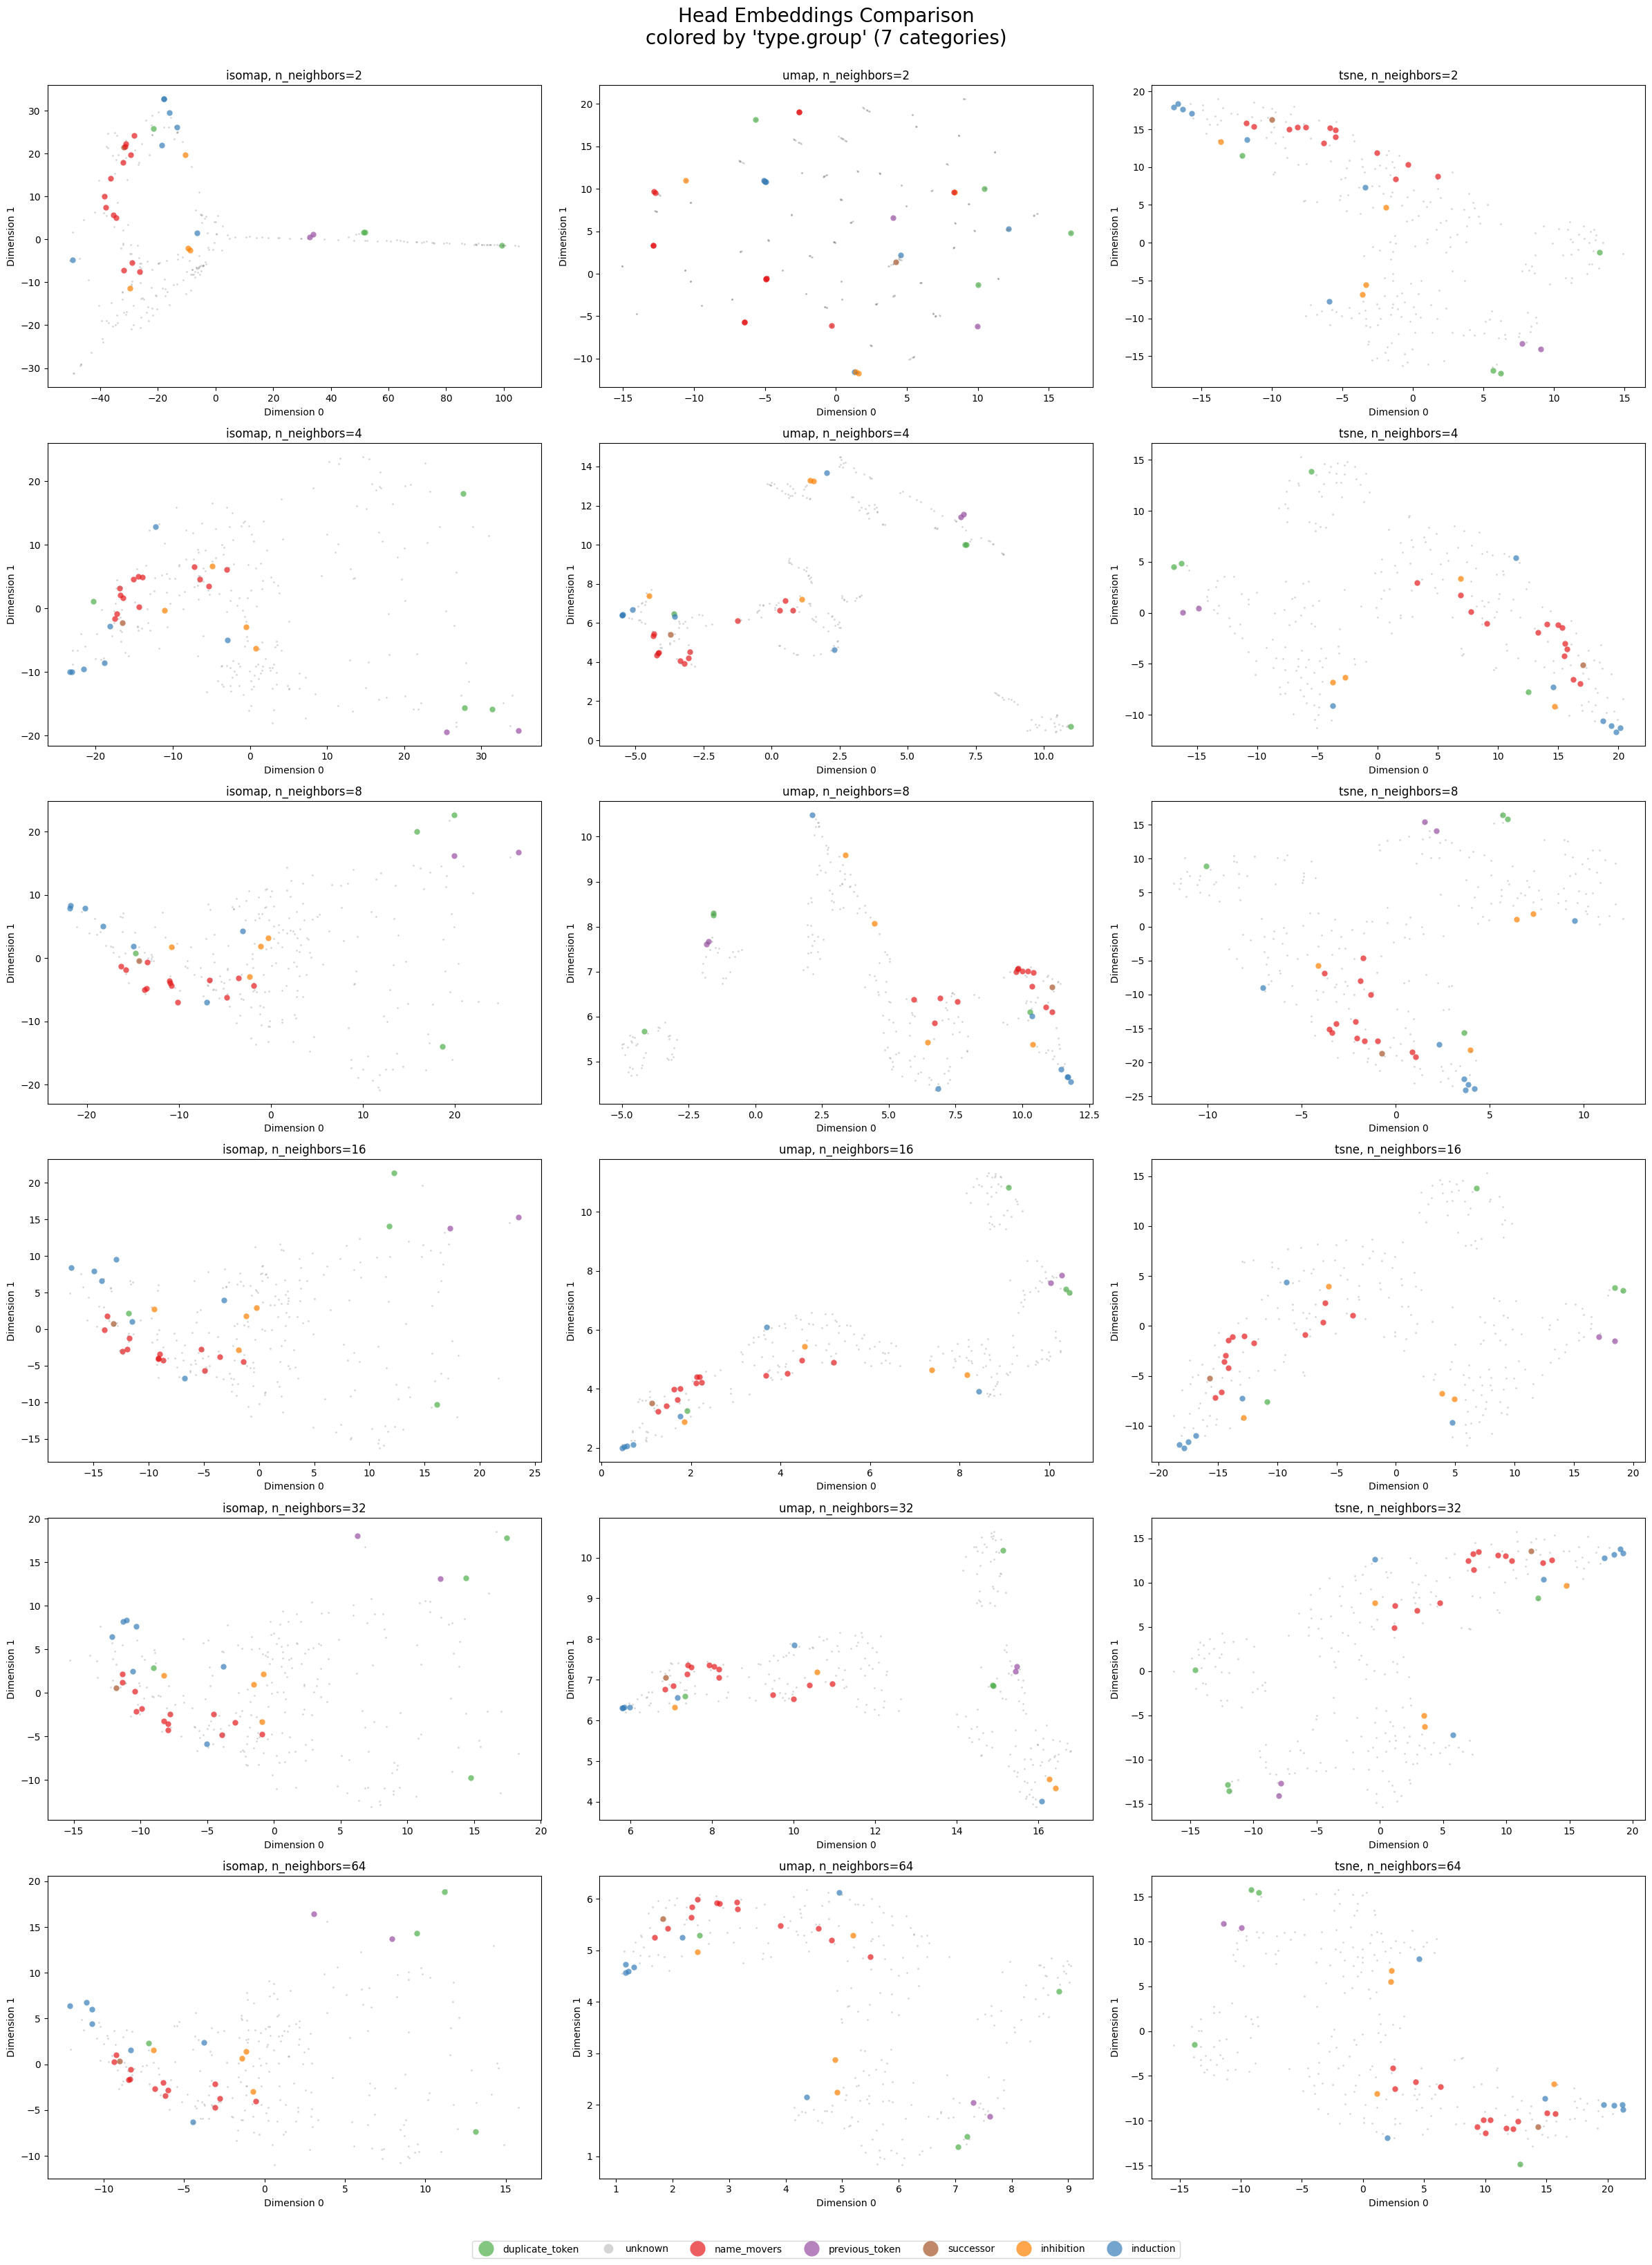

In [6]:
HEAD_EMBED_DF: pl.DataFrame = create_embedding_df_multi(
	head_dists=HEAD_DISTS,
	attnpedia=ATTENTIONPEDIA,
	embedding_methods=["isomap", "umap", "tsne", "pca"],
	n_components_list=[2, 3],
	n_neighbors_list=[2, 4, 8, 16, 32, 64],
	match_model=None,
	save_path=PATH_BASE / "head_embed",
)
_ = plot_head_embeddings_multi(
	HEAD_EMBED_DF,
	methods=["isomap", "umap", "tsne"],
	color_by="type.group",
	sizes=(6, 2),
	figsize=(24, 32),
)
plt.savefig("figures/head_embed.all.pdf", bbox_inches="tight")

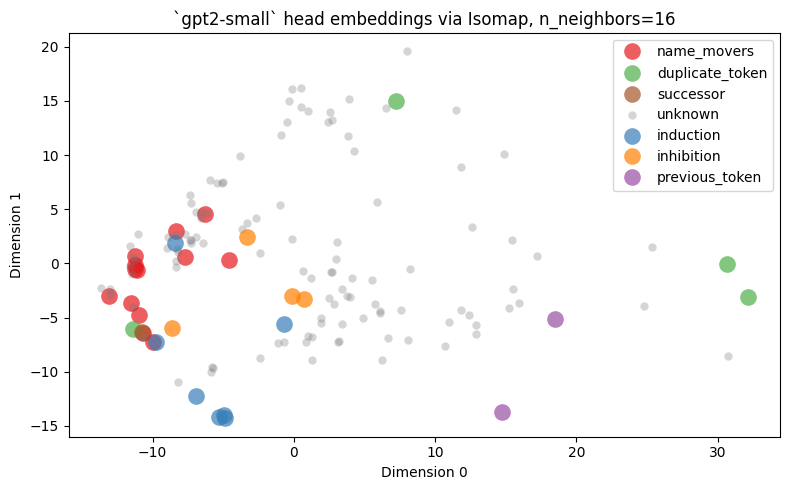

In [7]:
_ = plot_head_embeddings(
	df=HEAD_EMBED_DF_GPT2SMALL,
	prefix="embed.isomap.d2.b16",
	color_by="type.group",
	sizes=(12, 6),
	figsize=(8, 5),
	title="`gpt2-small` head embeddings via Isomap, n_neighbors=16",
)
plt.savefig("figures/head_embed.gpt2-small.isomap.b16.pdf", bbox_inches="tight")

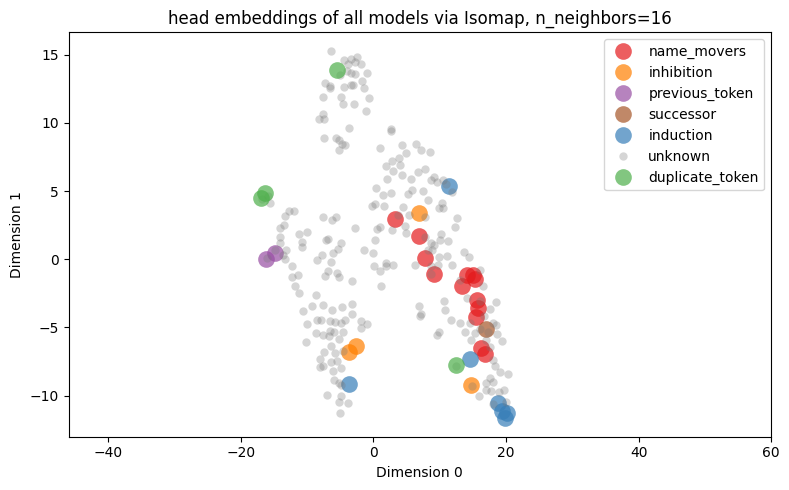

In [8]:
_ = plot_head_embeddings(
	df=HEAD_EMBED_DF,
	prefix="embed.tsne.d2.b4",
	color_by="type.group",
	sizes=(12, 6),
	figsize=(8, 5),
	title="head embeddings of all models via Isomap, n_neighbors=16",
	xlim=(-46, 60),
)
plt.savefig("figures/head_embed.ALL.tsne.b4.pdf", bbox_inches="tight")